In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_selfies_onehot=True)
molecules = qm9.get_molecules()
df = qm9.load()

2026-04-15 13:50:50.666 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-15 13:50:50.817 | INFO     | src.datasets:_sample_qm9_df:685 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-15 13:50:50.818 | INFO     | src.datasets:_add_requested_descriptors:126 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-15 13:50:50.818 | INFO     | src.features:compute_selfies_onehot:134 - Computing One-Hot Encodings...
2026-04-15 13:50:52.253 | INFO     | src.datasets:_add_requested_descriptors:149 - Added descriptor column(s): ['selfies_onehot']
2026-04-15 13:51:14.916 | SUCCESS  | src.datasets:get_molecules:1168 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).
2026-04-15 13:51:14.917 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-15 13:51:15.047 | INFO     | s

In [4]:
df.head(5)

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,selfies_onehot
str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[list[i64]]
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""O=C1CNC1""","""[H][N][C][Branch1][C][H][Branc…","""ketone""",10,"""Aliphatic Ring""",71,0,29,0.761845,12.992522,5,1,0,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,0,0,0,0,0,0,0,1,0,0,2,2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,"[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_132""","""C4H10O""","""[H]C([H])([H])C([H])([H])OC([H…","""[H]C([H])([H])C([H])([H])OC([H…","""Acyclic""","""[H][C][Branch1][C][H][Branch1]…","""ether""",15,"""Acyclic""",74,1,9,0.936769,12.976237,5,0,0,1.866667,4,0.0,0.0,1.0,0,1,4,0,0,4,6,31,1.209514,0,0,0,0,0,0,0,0,1,0,1,0.9301,50.619999,-6.756587,2.53338,9.289967,631.081787,3.704885,-6355.161621,-6354.975098,-6354.949219,-6355.981445,22.881001,-56.966496,-57.358181,-57.718079,-52.897472,17.9608,2.23958,2.09578,"[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_139""","""C3H4N2""","""[H]N1C([H])([H])[C@]1([H])C#N""","""[H]N1C([H])([H])[C@]1([H])C#N""","""C1CN1""","""[H][N][C][Branch1][C][H][Branc…","""""",9,"""Aliphatic Ring""",68,0,45,0.444793,13.026985,5,1,0,2.0,0,0.333333,0.0,0.666667,1,2,3,1,0,2,4,17,1.264596,0,0,0,0,0,0,0,0,0,0,2,2.8377,40.209999,-7.55116,0.206807,7.757967,386.555695,1.880987,-6152.69043,-6152.564453,-6152.538574,-6153.435547,15.572,-38.04356,-38.264439,-38.47002,-35.623112,17.103571,3.50921,3.35299,"[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_144""","""C3H5NO""","""[H]C(=O)N1C([H])([H])C1([H])[H…","""[H]C(=O)N1C([H])([H])C1([H])[H…","""C1CN1""","""[H][C][=Branch1][C][=O][N][C][…","""amide""",10,"""Aliphatic Ring""",71,0,20,0.761845,12.992522,5,1,0,2.0,0,0.0,0.333333,0.666667,0,1,4,0,1,2,4,20,1.261934,0,0,0,0,1,0,0,0,0,0,2,3.2517,40.77,-6.952509,-0.035375,6.917135,383.601288,2.16589,-6726.451172,-6726.317871,-6726.291992,-6727.207031,16.197001,-40.882473,-41.134586,-41.36591,-38.185608,14.7497,3.94953,3.42803,"[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"
"""qm9_149""","""C4H8O""","""[H]OC([H])([H])C1([H])C([H])([…","""[H]OC([H])([H])C1([H])C([H])([…","""C1CC1""","""[H][O][C][Branch1][C][H][Branc…","""alcohol""",13,"""Aliphatic Ring""",72,0,20,0.964858,12.880514,5,1,0,2.0,2,0.0,0.0,1.0,1,1,4,0,0,4,5,27,1.240861,0,1,0,0,0,0,0,0,0,0,1,1.3201,46.009998,-7.077682,2.1497,9.224659,468.622894,3.110261,-6321.884277,-6321.729004,-6321.703125,-6322.664062,20.059,-50.915638,-51.26128,-51.569748,-47.386292,12.75002,3.20516,2.88061,"[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]"


In [5]:
len(molecules[0:2])

2

In [6]:
plot_molecules_with_py3dmol(molecules[0:4])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [77]:
def vectorized_tanimoto_distance(onehot_list):
    """
    Computes the full Tanimoto distance matrix using matrix algebra.
    One-hot matrices are treated as binary fingerprints.
    """
    # 1. Flatten and stack into (N, D) matrix
    X = np.array([np.array(m).flatten() for m in onehot_list], dtype=np.float32)
    
    # 2. Compute dot products: (a dot b)
    # This represents the number of shared 'on' bits (intersection)
    intersection = X @ X.T
    
    # 3. Compute sums of 'on' bits: ||a||^2
    # For one-hot vectors, sum(x) is equivalent to the squared norm
    row_sums = np.sum(X, axis=1)
    
    # 4. Compute Tanimoto Similarity using broadcasting
    # denominator = |a| + |b| - (a dot b)
    denominator = row_sums[:, None] + row_sums[None, :] - intersection
    
    # 5. Handle potential division by zero for empty molecules
    # tanimoto = intersection / denominator
    similarity = np.divide(
        intersection, 
        denominator, 
        out=np.zeros_like(intersection), 
        where=denominator != 0
    )
    
    # 6. Return distance (1 - similarity)
    return 1 - similarity


# Usage
all_onehots = df['selfies_onehot'].to_list()
dist_matrix = vectorized_tanimoto_distance(all_onehots)

# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:02<00:00,  3.79it/s]


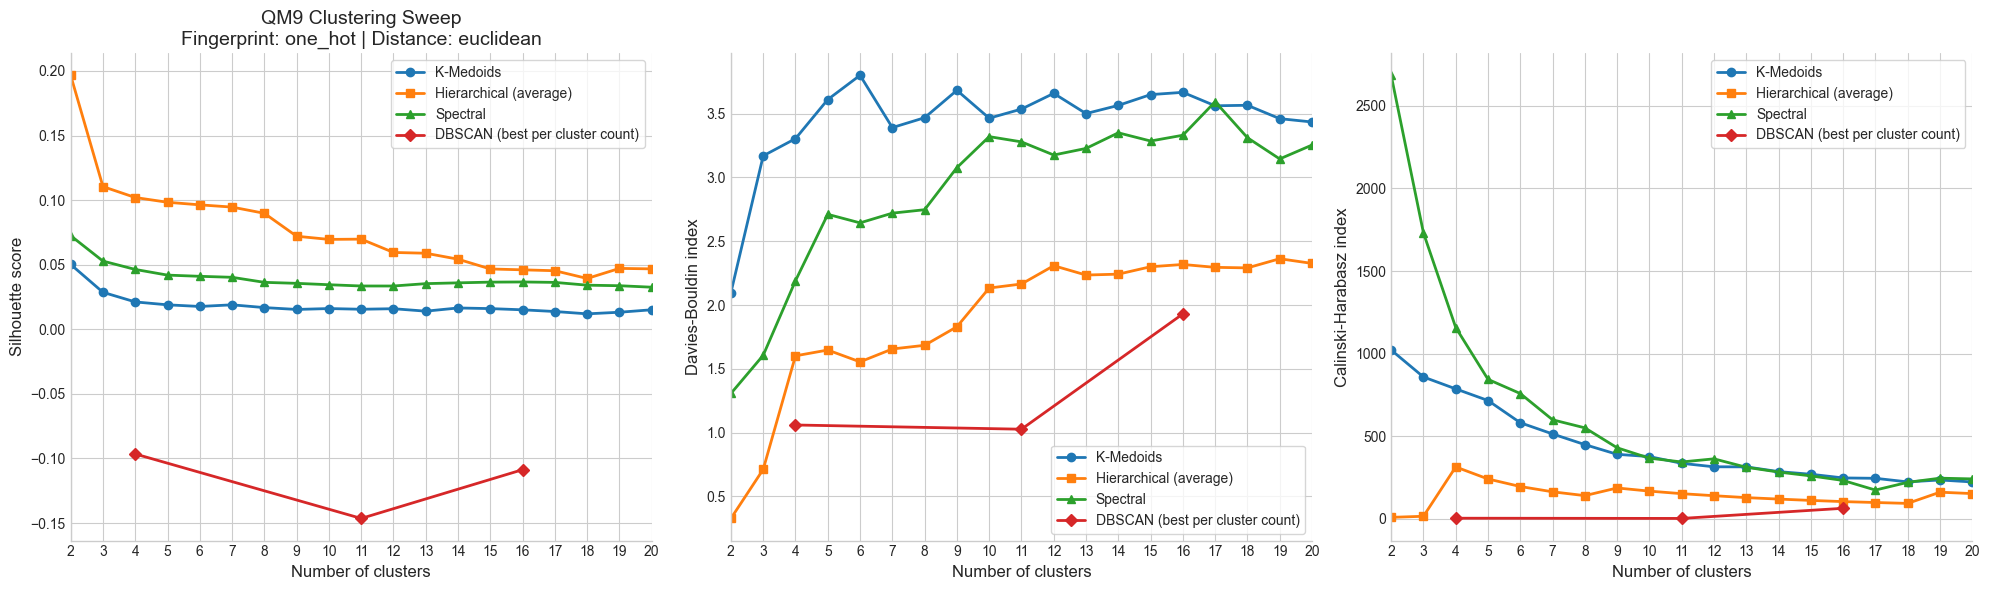

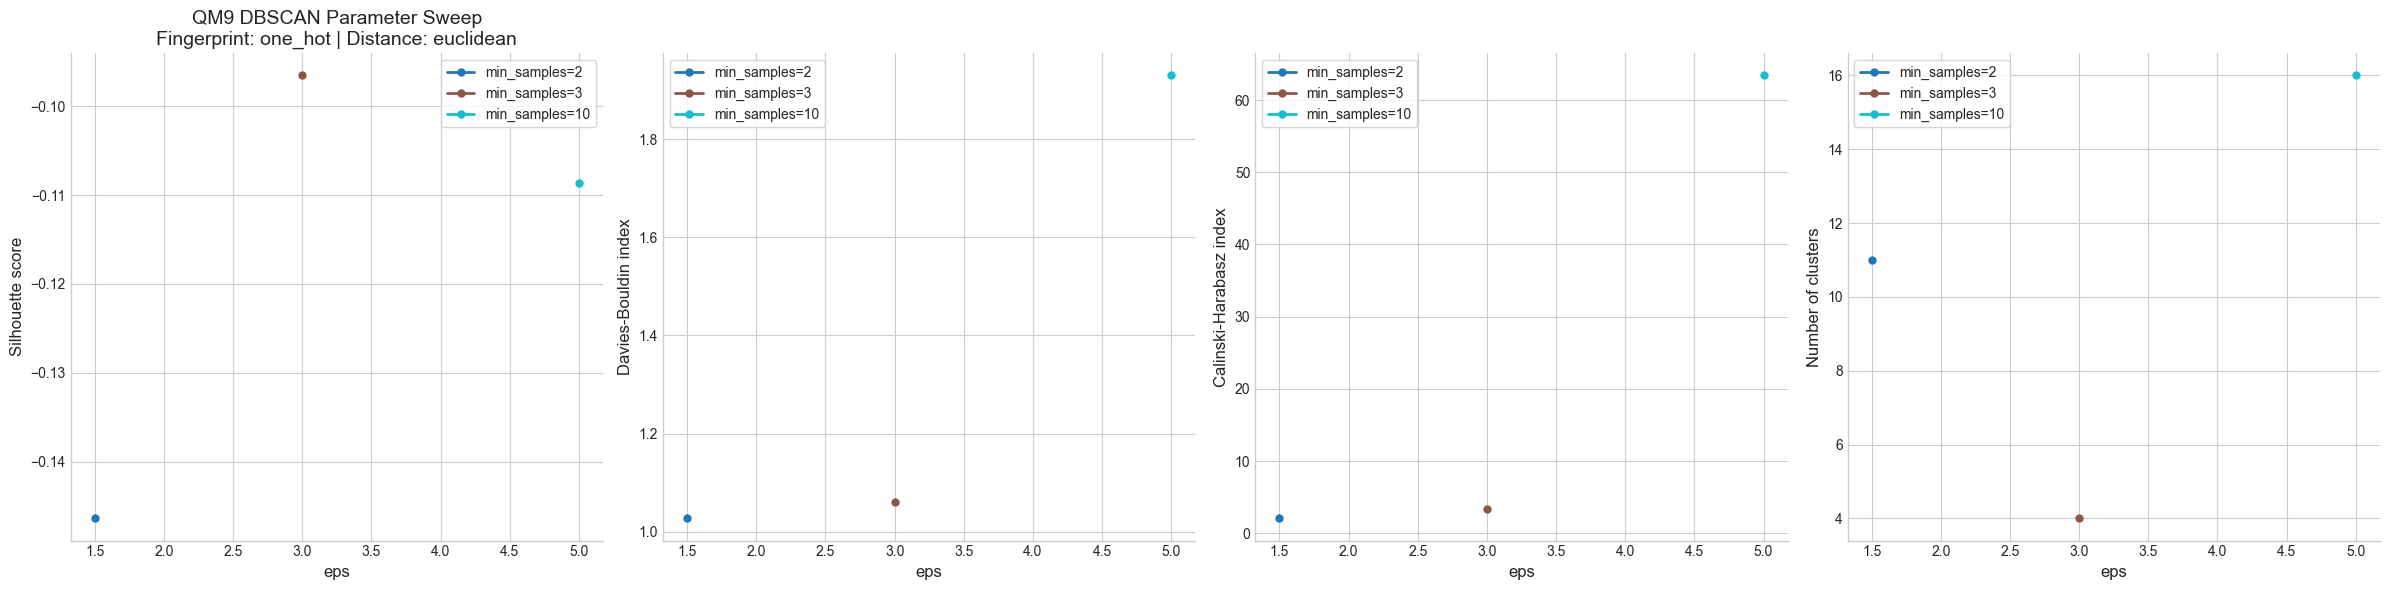

2026-04-15 13:52:20.394 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/one_hot/clustering_sweep_2_to_20_clusters.png
2026-04-15 13:52:20.395 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:842 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/one_hot/dbscan_parameter_sweep.png
2026-04-15 13:52:20.395 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/euclidean/one_hot/clustering_sweep_2_to_20_clusters.json


In [8]:
# out = evaluate_distance_matrix_clustering_sweep(
#     dist_matrix=dist_matrix,
#     fingerprint="one_hot",
#     distance_metric="euclidean",
#     dataset_name="qm9",
# )

In [71]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4966), np.int64(4967)), (np.int64(730), np.int64(731)), (np.int64(2645), np.int64(2646)), (np.int64(4274), np.int64(4276)), (np.int64(968), np.int64(969)), (np.int64(2387), np.int64(2388)), (np.int64(218), np.int64(4973)), (np.int64(452), np.int64(453)), (np.int64(253), np.int64(255)), (np.int64(3051), np.int64(3052))]


In [72]:
print(mols[0])

(Atoms(symbols='N2HFC2HC2NC', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='CNHNCFCHC2N', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [76]:
plot_molecules_with_py3dmol(mols[3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

In [97]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=2, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1]), array([4853,  147]))


In [98]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
link = linkage(dist_matrix, method='average')

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_34027/2314491329.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


In [87]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-15 14:19:14.940 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_hierarchical_projection.png


{'coords': array([[-5.0669985 ,  2.4381812 ],
        [-4.3753757 ,  0.9182374 ],
        [-4.7005634 ,  2.6638944 ],
        ...,
        [-4.238835  , -1.2189177 ],
        [ 0.8119743 ,  0.60153294],
        [-2.758121  , -2.0685558 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'hierarchical'}

In [88]:
average_numeric_by_cluster(df, "labels_hier")

labels_hier,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,4994,2.082684,18.018622,122.788947,0.094714,36.812575,0.855076,12.854911,8.785342,1.640969,0.181418,2.060403,2.302163,0.064652,0.236171,0.699178,0.918903,2.026632,6.506007,0.42491,1.32499,4.569283,6.352022,37.840208,1.262518,0.003004,0.338206,0.03364,0.130557,0.126552,0.001802,0.039447,0.122948,0.520825,0.003004,2.466159,2.696012,75.143564,-6.535812,0.299199,6.835019,1191.235509,4.054529,-11181.845322,-11181.614023,-11181.588349,-11182.755441,31.653288,-76.084415,-76.547583,-76.984995,-70.810935,3.40675,1.4015,1.117574,0.962155,0.0002,-0.993993,72.286744,17.260713,10.452543
1,6,2.289544,26.5,126.0,2.0,0.666667,0.909328,12.82887,9.0,1.166667,0.0,2.013333,5.5,0.0,0.0,1.0,0.166667,0.0,9.0,0.0,0.0,8.833333,7.166667,60.666667,1.242137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.322833,95.601667,-6.784705,2.181446,8.965698,1638.68099,6.654073,-9688.065755,-9687.75944,-9687.733724,-9689.057454,41.875667,-105.161552,-105.876602,-106.532103,-97.515391,2.529953,0.989792,0.813152,1.0,0.0,-1.0,100.0,0.0,0.0


- Clustering on unique selfies string and patterns - such as unique branching and number of atoms

# KMedoids

In [85]:
model_km = KMedoids(n_clusters=3, metric="precomputed", random_state=42)
labels_km = model_km.fit_predict(dist_matrix)
medoid_indices = model_km.medoid_indices_
print(medoid_indices)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)
medoids_df = df[medoid_indices]
print(medoids_df.select(["labels_km", "mol_id", "smiles", "scaffold_smiles"]))

[  4 112  91]
(array([0, 1, 2], dtype=uint64), array([2045, 1099, 1856]))
shape: (3, 4)
┌───────────┬──────────┬─────────────────────────────────┬─────────────────┐
│ labels_km ┆ mol_id   ┆ smiles                          ┆ scaffold_smiles │
│ ---       ┆ ---      ┆ ---                             ┆ ---             │
│ u64       ┆ str      ┆ str                             ┆ str             │
╞═══════════╪══════════╪═════════════════════════════════╪═════════════════╡
│ 0         ┆ qm9_149  ┆ [H]OC([H])([H])C1([H])C([H])([… ┆ C1CC1           │
│ 1         ┆ qm9_2666 ┆ [H]C([H])([H])C([H])([H])OC([H… ┆ Acyclic         │
│ 2         ┆ qm9_2217 ┆ [H]C#CC([H])([H])C1([H])C([H])… ┆ C1CCC1          │
└───────────┴──────────┴─────────────────────────────────┴─────────────────┘


In [89]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-15 13:53:29.253 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/one_hot/pca_kmedoids_projection.png


{'coords': array([[-45.611076 ,  22.047283 ],
        [-39.40808  ,   8.556431 ],
        [-42.39713  ,  24.192102 ],
        ...,
        [-38.570435 , -10.774124 ],
        [  6.8804493,   5.5927467],
        [-25.47282  , -18.561935 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/one_hot/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/one_hot'),
 'clustering_method': 'kmedoids'}

In [20]:
average_numeric_by_cluster(df, "labels_km")

labels_km,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,2045,1.986794,16.539853,122.054768,-0.080196,47.531051,0.804895,12.907483,8.705134,1.408802,0.324694,2.040771,2.25868,0.066156,0.355408,0.578436,1.131051,2.529095,5.970171,0.397066,1.815648,3.431296,6.291443,33.223472,1.262759,0.006357,0.438631,0.067482,0.162836,0.148655,0.000489,0.050367,0.133496,0.438631,0.007335,3.061125,3.061815,71.617971,-6.582515,-0.148798,6.433732,1162.880965,3.601781,-11484.381377,-11484.156045,-11484.130373,-11485.287326,30.3887,-70.657695,-71.06982,-71.469209,-65.809864,3.618657,1.428369,1.104659,0.983863,57.701711,30.366748,11.93154
1,1856,2.100854,17.944504,122.940733,0.084052,33.947737,0.878802,12.812497,8.842672,1.783944,0.126078,2.074735,2.001616,0.089011,0.199627,0.711361,0.865302,1.921336,6.50431,0.617457,1.251078,4.665409,6.35722,37.758082,1.264874,0.001078,0.310884,0.015625,0.120151,0.126078,0.001078,0.037716,0.121767,0.577586,0.0,2.308728,2.591537,75.661546,-6.507361,0.308197,6.815553,1172.907921,4.023862,-11133.568108,-11133.339644,-11133.313975,-11134.474148,31.502234,-76.28896,-76.752125,-77.18763,-71.028789,3.30675,1.419758,1.1403,0.990302,78.071121,12.553879,9.375
2,1099,2.23156,20.941765,123.916288,0.44859,21.508644,0.908682,12.82857,8.838944,1.828935,0.007279,2.072474,2.908098,0.020361,0.074721,0.904918,0.610555,1.258417,7.519563,0.149227,0.529572,6.547771,6.460419,46.694268,1.257979,0.0,0.195632,0.00091,0.087352,0.085532,0.00546,0.021838,0.104641,0.575068,0.0,1.612375,2.178814,80.940846,-6.498314,1.127906,7.626232,1277.391756,4.962979,-10692.267157,-10692.019559,-10691.993873,-10693.192373,34.31732,-85.995672,-86.555196,-87.067775,-79.89472,3.17653,1.318418,1.101561,0.742493,89.808917,0.727934,9.463148


# Spectral

In [ ]:
model_spectral = SpectralClustering(
                n_clusters=2,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

In [92]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [93]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-15 14:23:54.591 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_spectral_projection.png


{'coords': array([[-5.0669985 ,  2.4381812 ],
        [-4.3753757 ,  0.9182374 ],
        [-4.7005634 ,  2.6638944 ],
        ...,
        [-4.238835  , -1.2189177 ],
        [ 0.8119743 ,  0.60153294],
        [-2.758121  , -2.0685558 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'spectral'}

In [94]:
average_numeric_by_cluster(df, "labels_spectral")

labels_spectral,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,4999,2.08304,18.030206,122.792759,0.097019,36.766753,0.855185,12.854823,8.785557,1.640528,0.181036,2.060359,2.306461,0.064547,0.235775,0.699679,0.918184,2.024005,6.509502,0.424285,1.322865,4.575315,6.353071,37.871774,1.262485,0.003001,0.337868,0.033607,0.130426,0.126425,0.0018,0.039408,0.122825,0.520304,0.003001,2.463093,2.693116,75.16967,-6.535825,0.302012,6.837844,1191.779717,4.058095,-11179.808432,-11179.577033,-11179.551359,-11180.71866,31.667077,-76.123404,-76.586917,-77.024627,-70.846687,3.405171,1.401081,1.117257,0.0012,0.962392,-0.993999,72.334467,17.223445,10.442088
1,1,1.545455,11.0,123.0,0.0,49.0,0.638198,13.138502,9.0,1.0,1.0,2.0,0.0,0.2,0.8,0.0,0.0,3.0,4.0,1.0,4.0,0.0,6.0,17.0,1.303912,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.9366,67.389999,-7.964772,-2.468073,5.4967,1155.412476,1.827653,-12401.580078,-12401.399414,-12401.374023,-12402.435547,24.056,-55.645657,-55.889771,-56.146702,-52.312183,6.03786,1.02362,0.87524,0.0,0.0,-1.0,0.0,100.0,0.0


# DBSCAN 

In [ ]:
model_db = DBSCAN(
    eps=3,
    min_samples=3,
    metric='precomputed'
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3]), array([4988,    3,    3,    3,    3]))


In [67]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [95]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-15 14:25:33.454 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png


{'coords': array([[-5.0669985 ,  2.4381812 ],
        [-4.3753757 ,  0.9182374 ],
        [-4.7005634 ,  2.6638944 ],
        ...,
        [-4.238835  , -1.2189177 ],
        [ 0.8119743 ,  0.60153294],
        [-2.758121  , -2.0685558 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'dbscan'}

In [96]:
average_numeric_by_cluster(df, "labels_db")

labels_db,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-1,4988,2.083551,18.036287,122.802727,0.097233,36.725942,0.855274,12.854947,8.786087,1.642542,0.179832,2.060567,2.306536,0.064482,0.234671,0.700847,0.916199,2.023657,6.510024,0.424018,1.31676,4.5834,6.352646,37.893144,1.262527,0.002606,0.338613,0.032277,0.129711,0.125902,0.001804,0.039495,0.122895,0.521451,0.003007,2.461909,2.69313,75.175974,-6.537287,0.303871,6.841165,1191.663706,4.05991,-11179.813277,-11179.581873,-11179.556199,-11180.723473,31.670265,-76.14111,-76.604853,-77.04272,-70.862558,3.40426,1.401306,1.117584,0.001203,0.963312,0.0002,72.493986,17.101043,10.404972
0,3,1.783333,15.333333,120.0,0.0,63.666667,0.829935,12.818618,8.666667,1.0,1.0,2.0,2.333333,0.0,1.0,0.0,2.666667,2.666667,7.0,0.0,5.666667,0.0,7.0,27.333333,1.242699,0.666667,0.0,1.333333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0516,74.926666,-4.954286,0.013606,4.967892,1096.111328,3.268369,-11380.70931,-11380.496745,-11380.471029,-11381.575195,30.489,-69.308784,-69.686925,-70.055278,-64.775548,4.01184,1.390507,1.02421,0.0,0.0,0.0,0.0,100.0,0.0
1,3,1.875,16.0,120.666667,0.0,53.666667,0.828206,12.850359,8.666667,0.0,0.0,1.875,1.666667,0.355556,0.288889,0.355556,1.333333,1.666667,5.0,2.0,1.666667,2.0,8.0,30.0,1.23978,0.0,0.0,0.0,0.666667,1.333333,0.0,0.0,0.333333,0.0,0.0,3.0,2.554,74.243332,-6.631415,-0.909767,5.722554,1688.651449,3.374547,-11390.197266,-11389.922526,-11389.896484,-11391.22819,33.672667,-69.720993,-70.06307,-70.448583,-65.15964,4.399413,0.733157,0.666973,0.0,0.0,0.0,0.0,0.0,100.0
2,3,1.819902,13.0,112.666667,0.0,45.666667,0.825268,12.678193,8.333333,1.0,1.0,2.0,1.333333,0.055556,0.944444,0.0,1.0,1.666667,6.333333,0.333333,5.333333,0.0,5.0,23.666667,1.259053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.666667,4.305867,70.879999,-6.64502,-1.649917,4.994197,1013.649618,2.586642,-10665.569987,-10665.380208,-10665.354818,-10666.427409,25.281,-62.266242,-62.577875,-62.886252,-58.439823,4.332127,1.636597,1.140233,0.0,2.0,0.0,0.0,100.0,0.0
3,3,1.825,15.333333,121.333333,0.0,56.0,0.716298,12.959603,8.666667,1.0,1.0,2.0,3.0,0.0,0.733333,0.266667,1.666667,3.0,6.0,0.0,3.666667,1.333333,6.0,28.0,1.252643,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.666667,1.9182,67.553335,-5.957479,-0.259415,5.698064,1149.470561,3.240541,-11681.958008,-11681.735352,-11681.709635,-11682.880859,29.386667,-66.931101,-67.299561,-67.667931,-62.446019,3.268897,1.344313,1.013537,0.0,0.0,0.0,0.0,100.0,0.0
